## 0. Setup — Google Drive / Path to directories & Dependancies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MVA/NLP')

sys.path.append(str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Exists: {PROJECT_ROOT.exists()}")

PROJECT_ROOT = /content/drive/MyDrive/MVA/NLP
Exists: True


In [3]:
!pip install -q jiwer soundfile torchaudio scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.5 MB/s eta 0:00:00


## 1. Configuration — Languages and Hyperparameters

In [ ]:
# Commonvoice experiment setup

LANGUAGES = [
    "swa",  # Swahili
    "fra",  # Français
    "deu",  # Allemand
    "spa",  # Espagnol
    "ita",  # Italien
    "por",  # Portugais
    "pol",  # Polonais
    "nld",  # Néerlandais
    "rus",  # Russe
    "tur",  # Turc
    "ara",  # Arabe
    "zho",  # Chinois
    "jpn",  # Japonais
    "kor",  # Coréen
    "hin",  # Hindi
    "vie",  # Vietnamien
    "ind",  # Indonésien
    "cat",  # Catalan
    "cym",  # Gallois
    "est",  # Estonien
]

assert len(LANGUAGES) == 20, f"There should be exactly 20 languages not {len(LANGUAGES)}"

# Mapping
LANG2IDX = {lang: idx for idx, lang in enumerate(LANGUAGES)}
IDX2LANG = {idx: lang for lang, idx in LANG2IDX.items()}
NUM_CLASSES = len(LANGUAGES)

print(f"{NUM_CLASSES} languages to train on:")
for i, lang in enumerate(LANGUAGES):
    print(f"  [{i:2d}] {lang}")

20 languages to train on:
  [ 0] swa
  [ 1] fra
  [ 2] deu
  [ 3] spa
  [ 4] ita
  [ 5] por
  [ 6] pol
  [ 7] nld
  [ 8] rus
  [ 9] tur
  [10] ara
  [11] zho
  [12] jpn
  [13] kor
  [14] hin
  [15] vie
  [16] ind
  [17] cat
  [18] cym
  [19] est


In [4]:
# ALFFA experiment
LANGUAGES = [
    "swa",
    "amh",
    "wol"
]


assert len(LANGUAGES) == 3, f" There should be exactly 3 languages not{len(LANGUAGES)}"

# Mapping
LANG2IDX = {lang: idx for idx, lang in enumerate(LANGUAGES)}
IDX2LANG = {idx: lang for lang, idx in LANG2IDX.items()}
NUM_CLASSES = len(LANGUAGES)

print(f"{NUM_CLASSES} languages to train on:")
for i, lang in enumerate(LANGUAGES):
    print(f"  [{i:2d}] {lang}")

3 languages to train on:
  [ 0] swa
  [ 1] amh
  [ 2] wol


In [5]:
CONFIG = {
    # Data
    "data_size": "10min", # '10min' or '1h'
    "dataset_source": "ALFFA", # set the parent folder with the data here (switch to commonvoice)

    # Training
    "batch_size": 8,
    "grad_accumulation": 4,
    "learning_rate": 1e-4,
    "weight_decay": 1e-6,
    "target_iterations": 1500,
    "eval_every": 5,
    "save_every": 100,
    "num_workers": 0,

    # Choose of pooling type in the lid
    "pooling": "mean", # 'mean', 'max' or 'CLS'
    "dropout": 0.1,

    # Experiment
    "experiment_name": "lid_3langs_10min",
    "seed": 42,
}

# Folders
DATA_DIR = PROJECT_ROOT / "data" / CONFIG["dataset_source"]
RESULTS_DIR = PROJECT_ROOT / "results" / "lid"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints" / "lid"
FIGURES_DIR = PROJECT_ROOT / "figures" / "lid"

for d in [RESULTS_DIR, CHECKPOINTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR = {DATA_DIR}")
print(f"Exists  : {DATA_DIR.exists()}")

DATA_DIR = /content/drive/MyDrive/MVA/NLP/data/ALFFA
Exists  : True


## 2. Imports

In [6]:
import json
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import confusion_matrix, classification_report
from transformers import HubertModel, Wav2Vec2Model

from src.data import parse_transcript_file, fix_audio_extension, ASRDataset
from src.train_utils import set_seed, save_checkpoint, count_parameters


set_seed(CONFIG["seed"])
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [7]:
MODELS = {
    "mHuBERT-147": {
        "hf_id": "utter-project/mHuBERT-147-base-3rd-iter",
        "model_class": HubertModel,
        "type": "multilingual",
    },
    "XLSR-53": {
        "hf_id": "facebook/wav2vec2-large-xlsr-53",
        "model_class": Wav2Vec2Model,
        "type": "multilingual",
    },
    "HuBERT-base": {
        "hf_id": "facebook/hubert-base-ls960",
        "model_class": HubertModel,
        "type": "monolingual",
    },
    "wav2vec2-base": {
        "hf_id": "facebook/wav2vec2-base",
        "model_class": Wav2Vec2Model,
        "type": "monolingual",
    },
    "XLS-R-300M": {
    "hf_id": "facebook/wav2vec2-xls-r-300m",
    "model_class": Wav2Vec2Model,
    "type": "multilingual",
},
}

## 3. Dataset LID — Adaptation of ASRdataset

In [8]:
class LIDDataset(Dataset):
    """
    Extend ASRdataset to LID
    """
    def __init__(self, df, audio_dir, lang_idx):
        """
        Args:
            df: DataFrame [utt_id, audio_filename, text]
            audio_dir: Path
            lang_idx : int — index mapping
        """
        self.asr_dataset = ASRDataset(df, audio_dir)
        self.lang_idx = lang_idx

    def __len__(self):
        return len(self.asr_dataset)

    def __getitem__(self, idx):
        sample = self.asr_dataset[idx]
        return {
            "audio": sample["audio"],
            "label": torch.tensor(self.lang_idx, dtype=torch.long),
        }

In [9]:
def load_split(split):
    """
    Load and build a concaneted dataset for a split (train, dev, test).
    """
    datasets = []
    skipped = []
    size = CONFIG["data_size"]

    for lang in LANGUAGES:
        lang_dir = DATA_DIR / lang
        transcript = lang_dir / f"transcript_{size}_{split}.txt"
        audio_dir = lang_dir / "wav"

        if not transcript.exists():
            print(f" [{lang}] not transcript found : {transcript}")
            skipped.append(lang)
            continue

        # Build dataset for each language
        df = parse_transcript_file(transcript)
        df = fix_audio_extension(df)
        ds = LIDDataset(df, audio_dir, lang_idx=LANG2IDX[lang])
        datasets.append(ds)

    if skipped:
        print(f"\n Ignored languages ({len(skipped)}) : {skipped}")

    total = sum(len(d) for d in datasets)
    print(f"\n Split '{split}' : {total} on {len(datasets)} languages")
    # Aggreagate different languages into one dataset
    return ConcatDataset(datasets)


print("=" * 50)
print("Loading data...")
print("=" * 50)
train_dataset = load_split("train")
dev_dataset   = load_split("dev")
test_dataset  = load_split("test")

Loading data...
Parsed 175 samples from /content/drive/MyDrive/MVA/NLP/data/ALFFA/swa/transcript_10min_train.txt
Loaded 175 samples from                utt_id        audio_filename  \
0    ALFFA_swa_000000  ALFFA_swa_000000.wav   
1    ALFFA_swa_000001  ALFFA_swa_000001.wav   
2    ALFFA_swa_000002  ALFFA_swa_000002.wav   
3    ALFFA_swa_000003  ALFFA_swa_000003.wav   
4    ALFFA_swa_000004  ALFFA_swa_000004.wav   
..                ...                   ...   
170  ALFFA_swa_000170  ALFFA_swa_000170.wav   
171  ALFFA_swa_000171  ALFFA_swa_000171.wav   
172  ALFFA_swa_000172  ALFFA_swa_000172.wav   
173  ALFFA_swa_000173  ALFFA_swa_000173.wav   
174  ALFFA_swa_000174  ALFFA_swa_000174.wav   

                                                  text  
0                  mwendesha mashtaka mkuu wa icc luis  
1           naam leo mkanyia mtaalamu wa swahili blues  
2            za viwandani linalotishia hali ya baadaye  
3    wananchi wa rwanda hapo kesho wanataraji kuufa...  
4            

In [10]:
def lid_collate_fn(batch):
    audios = [item["audio"] for item in batch]
    labels = torch.stack([item["label"] for item in batch])  # (B,)

    audio_lengths = torch.tensor([len(a) for a in audios])
    audios_padded = torch.nn.utils.rnn.pad_sequence(
        audios, batch_first=True, padding_value=0.0
    )  # (B, T_max)

    return {
        "audios": audios_padded,
        "audio_lengths": audio_lengths,
        "labels": labels,
    }

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=lid_collate_fn,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=lid_collate_fn,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=lid_collate_fn,
    num_workers=CONFIG["num_workers"],
)

print(f"Train batches: {len(train_loader)}")
print(f"Dev batches: {len(dev_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches : 52
Dev batches : 51
Test batches : 50


## 4. LinearDecoder + LID Model

In [12]:
def make_pad_mask(lengths, xs=None, length_dim=1):
    """
    Create the mask for padding.
    """
    bs = lengths.shape[0]
    maxlen = xs.shape[length_dim] if xs is not None else lengths.max().item()

    mask = torch.arange(maxlen, device=lengths.device).unsqueeze(0)  # (1, T)
    mask = mask >= lengths.unsqueeze(1)  # (B, T)

    if xs is not None and xs.dim() == 3:
        mask = mask.unsqueeze(-1)  # (B, T, 1)

    return mask

In [13]:
class LinearDecoder(nn.Module):
    """
    Reproduction of the code from ML-SUPERB.
    """
    def __init__(self, encoder_output_size, num_classes, pooling="mean", dropout=0.0):
        super().__init__()
        self.pooling = pooling
        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else None
        self.linear_out = nn.Linear(encoder_output_size, num_classes)

    def forward(self, encoder_out, encoder_out_lens):
        """
        Args:
            encoder_out: (B, T, D)
            encoder_out_lens: (B,)
        Returns:
            logits: (B, num_classes)
        """

        mask = make_pad_mask(encoder_out_lens, encoder_out, length_dim=1)\
               .to(encoder_out.device)  # (B, T, 1)

        if self.dropout is not None:
            encoder_out = self.dropout(encoder_out)

        if self.pooling == "mean":
            unmasked = (~mask).to(dtype=encoder_out.dtype) # (B, T, 1)
            pooled = (encoder_out * unmasked).sum(dim=1) # (B, D)
            pooled = pooled / unmasked.sum(dim=1).clamp(min=1e-9) # (B, D)

        elif self.pooling == "max":
            filled = encoder_out.masked_fill(mask, float("-inf")) # (B, T, D)
            pooled, _ = filled.max(dim=1) # (B, D)

        elif self.pooling == "CLS":
            pooled = encoder_out[:, 0, :] # (B, D)

        return self.linear_out(pooled) # (B, num_classes)

In [14]:
class LIDModel(nn.Module):
    """
    LID model = Frozen Encoder + LinearDecoder
    """
    def __init__(self, encoder, encoder_output_size, num_classes,
                 pooling="mean", dropout=0.1):
        super().__init__()
        self.encoder = encoder
        self.decoder = LinearDecoder(
            encoder_output_size=encoder_output_size,
            num_classes=num_classes,
            pooling=pooling,
            dropout=dropout,
        )

    def forward(self, audios, audio_lengths):
        B, T = audios.shape
        attention_mask = torch.arange(T, device=audios.device)\
                            .unsqueeze(0)\
                            .expand(B, -1)
        attention_mask = (attention_mask < audio_lengths.unsqueeze(1)).long()

        outputs = self.encoder(
            input_values=audios,
            attention_mask=attention_mask,
        )
        encoder_out = outputs.last_hidden_state
        encoder_out_lens = (audio_lengths // 320).clamp(min=1)
        logits = self.decoder(encoder_out, encoder_out_lens)
        return logits

In [15]:
CURRENT_MODEL = "XLS-R-300M"


model_cfg = MODELS[CURRENT_MODEL]
CONFIG["experiment_name"] = f"lid_ALFFA_{CURRENT_MODEL}_10min"

encoder = model_cfg["model_class"].from_pretrained(model_cfg["hf_id"])
for param in encoder.parameters():
    param.requires_grad = False

hidden_size = encoder.config.hidden_size
print(f"Model: {CURRENT_MODEL}  ({model_cfg['type']})")
print(f"Hidden size: {hidden_size}")

model = LIDModel(
    encoder=encoder,
    encoder_output_size=hidden_size,
    num_classes=NUM_CLASSES,
    pooling=CONFIG["pooling"],
    dropout=CONFIG["dropout"],
).to(device)

count_parameters(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: XLS-R-300M  (multilingual)
Hidden size: 1024
Total params: 315.4M
Trainable params: 0.00M (0.0%)
Frozen params: 315.4M


(315441795, 3075)

## 5. Training

In [16]:
def train_epoch_lid(model, loader, criterion, optimizer, device, grad_accum=1):
    """Une époque d'entraînement LID avec gradient accumulation."""
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc="Train")
    for batch_idx, batch in enumerate(pbar):
        audios = batch["audios"].to(device)
        audio_lengths = batch["audio_lengths"].to(device)
        labels = batch["labels"].to(device) # (B,)

        logits = model(audios, audio_lengths) # (B, num_classes)
        loss = criterion(logits, labels) / grad_accum
        loss.backward()

        if (batch_idx + 1) % grad_accum == 0:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item()*grad_accum:.4f}",
                          "acc":  f"{correct/total:.3f}"})


    if len(loader) % grad_accum != 0:
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate_lid(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    pbar = tqdm(loader, desc="Eval")
    for batch in pbar:
        audios = batch["audios"].to(device)
        audio_lengths = batch["audio_lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(audios, audio_lengths)
        loss = criterion(logits, labels)
        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}",
                          "acc":  f"{correct/total:.3f}"})

    return total_loss / len(loader), correct / total

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)


steps_per_epoch = len(train_loader) // CONFIG["grad_accumulation"]
num_epochs = max(1, CONFIG["target_iterations"] // steps_per_epoch)
print(f"Steps/epoch : {steps_per_epoch}")
print(f"Num epoch : {num_epochs}  (for ~{CONFIG['target_iterations']} iterations)")

Steps/epoch : 13
Num epoch : 115  (for ~1500 iterations)


In [ ]:
history = {"train_loss": [], "train_acc": [], "dev_loss": [], "dev_acc": []}
best_dev_acc = 0.0
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch}/{num_epochs}")
    print(f"{'='*70}")

    train_loss, train_acc = train_epoch_lid(
        model, train_loader, criterion, optimizer, device,
        grad_accum=CONFIG["grad_accumulation"]
    )
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    # Eval
    if epoch % CONFIG["eval_every"] == 0 or epoch == num_epochs:
        dev_loss, dev_acc = evaluate_lid(model, dev_loader, criterion, device)
        history["dev_loss"].append(dev_loss)
        history["dev_acc"].append(dev_acc)
        print(f"\nDev loss: {dev_loss:.4f} | acc: {dev_acc:.4f}")

        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            save_checkpoint(
                model, optimizer, epoch,
                path=CHECKPOINTS_DIR / f"{CONFIG['experiment_name']}_best.pt",
                dev_loss=dev_loss,
                config=CONFIG,
            )
            print(f"Best model saved (acc={best_dev_acc:.4f})")

    # Save
    if epoch % CONFIG["save_every"] == 0:
        save_checkpoint(
            model, optimizer, epoch,
            path=CHECKPOINTS_DIR / f"{CONFIG['experiment_name']}_epoch{epoch}.pt",
            config=CONFIG,
        )

    print(f"Training loss: {train_loss:.4f} | acc: {train_acc:.4f}")

elapsed = time.time() - start_time
print(f"\n Training finished in {elapsed/60:.1f} min")
print(f"Best accuracy dev : {best_dev_acc:.4f}")


Epoch 1/115


Train:   0%|          | 0/52 [00:00<?, ?it/s]

Training loss: 1.1005 | acc: 0.2995

Epoch 2/115


Train:   0%|          | 0/52 [00:00<?, ?it/s]

Training loss: 1.0849 | acc: 0.4372

Epoch 3/115


...

Train:   0%|          | 0/52 [00:00<?, ?it/s]

Training loss: 0.8960 | acc: 0.6594

Epoch 115/115


Train:   0%|          | 0/52 [00:00<?, ?it/s]

Eval:   0%|          | 0/51 [00:00<?, ?it/s]


Dev loss: 0.9964 | acc: 0.4392
Training loss: 0.8957 | acc: 0.6787

 Training finished in 181.7 min
Best accuracy dev : 0.6476


## 6. Training curves

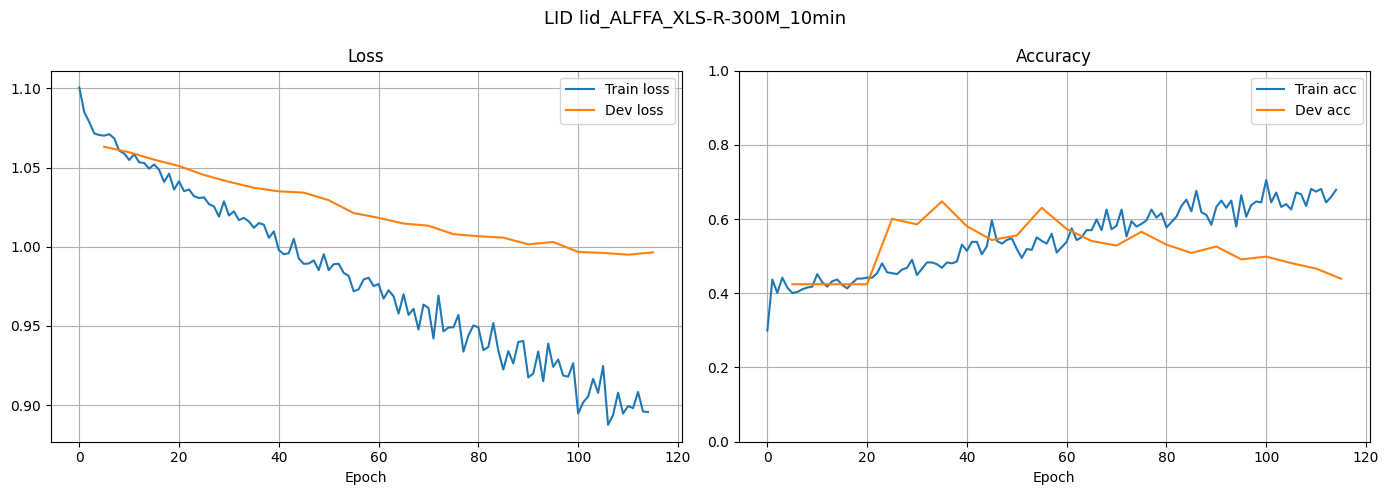

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train loss")
if history["dev_loss"]:
    dev_epochs = list(range(CONFIG["eval_every"], num_epochs + 1, CONFIG["eval_every"]))
    if num_epochs not in dev_epochs:
        dev_epochs.append(num_epochs)
    axes[0].plot(dev_epochs[:len(history["dev_loss"])],
                 history["dev_loss"], label="Dev loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train acc")
if history["dev_acc"]:
    axes[1].plot(dev_epochs[:len(history["dev_acc"])],
                 history["dev_acc"], label="Dev acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"LID {CONFIG['experiment_name']}", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"training_curves_{CONFIG['experiment_name']}.png", dpi=150)
plt.show()

## 7. Final Eval on test set

In [18]:
# Load best checkpoint (in terms of acc)
best_ckpt = CHECKPOINTS_DIR / f"{CONFIG['experiment_name']}_best.pt"
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Best checkpoint loaded at epoch {ckpt['epoch']}")

test_loss, test_acc = evaluate_lid(model, test_loader, criterion, device)
print(f"\n Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

Best checkpoint loaded at epoch 35


Eval:   0%|          | 0/50 [00:00<?, ?it/s]


 Test Accuracy: 0.6884  (68.84%)
Test Loss: 1.0097


## 8. Confusion matrix

On my first experiment with ALFFA, Swa was always recognised easily compared to the two other languages. Can be seen during eval at training as the batch are not random and the acc decreases from 1 to real acc during eval.

In [19]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    for batch in tqdm(loader, desc="Inference"):
        audios = batch["audios"].to(device)
        audio_lengths = batch["audio_lengths"].to(device)
        labels = batch["labels"]

        logits = model(audios, audio_lengths)
        preds = logits.argmax(dim=-1).cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    return all_labels, all_preds


all_labels, all_preds = get_predictions(model, test_loader, device)

Inference:   0%|          | 0/50 [00:00<?, ?it/s]

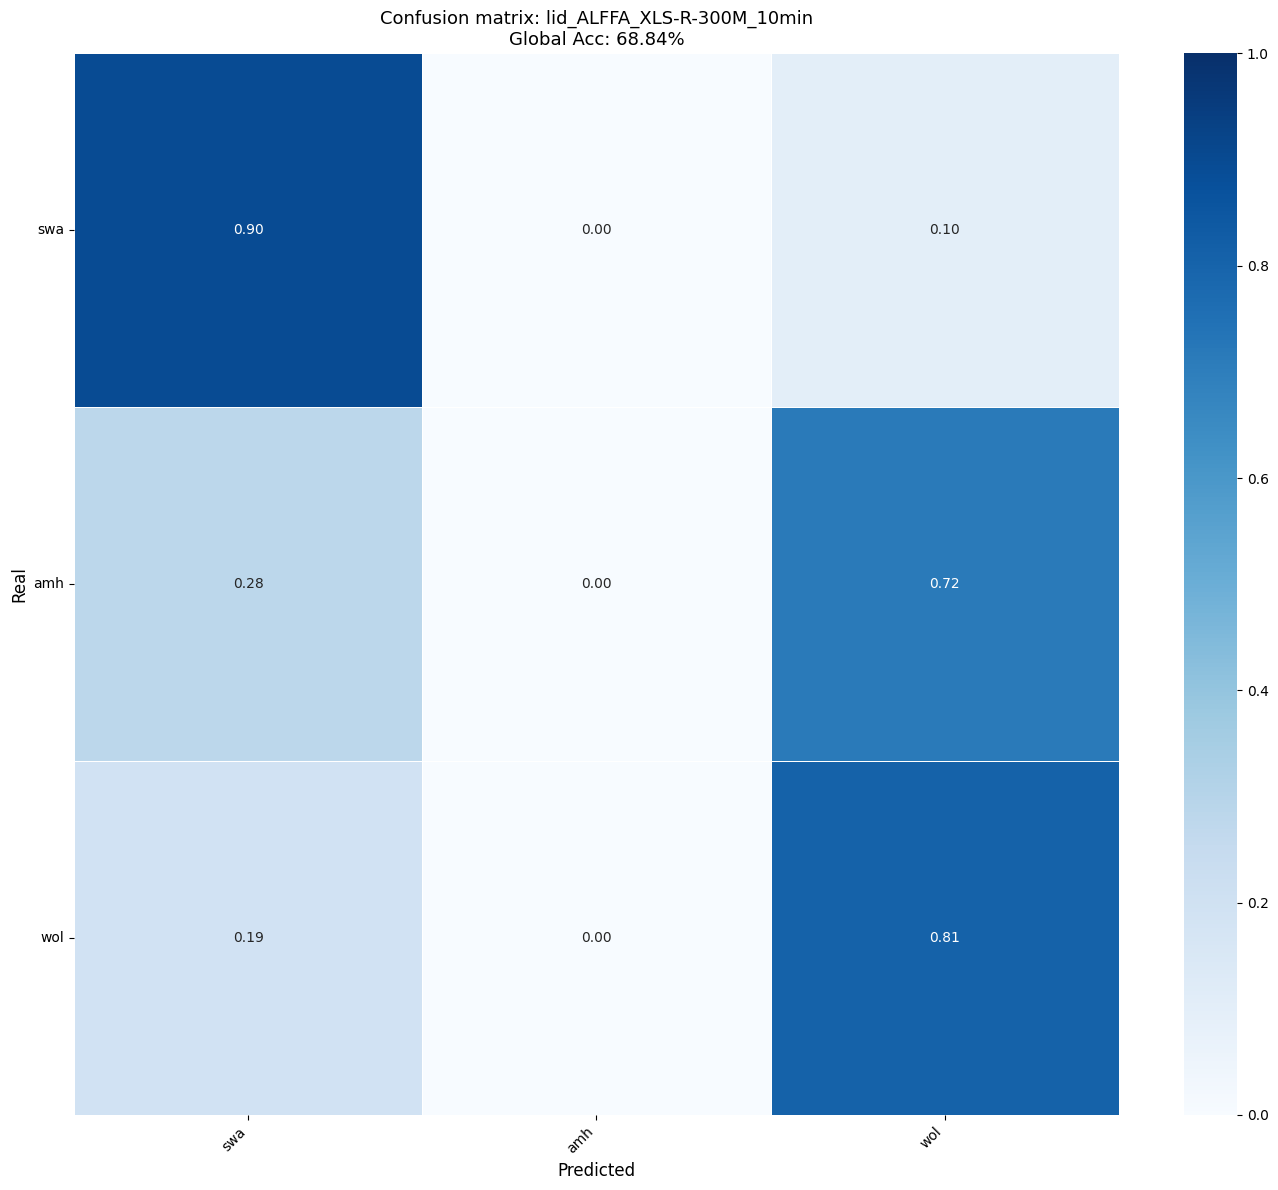


 Languages report:
              precision    recall  f1-score   support

         swa      0.758     0.897     0.822       175
         amh      0.000     0.000     0.000        78
         wol      0.613     0.807     0.696       145

    accuracy                          0.688       398
   macro avg      0.457     0.568     0.506       398
weighted avg      0.557     0.688     0.615       398



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LANGUAGES,
    yticklabels=LANGUAGES,
    ax=ax,
    linewidths=0.5,
    vmin=0, vmax=1,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title(f"Confusion matrix: {CONFIG['experiment_name']}\n"
             f"Global Acc: {test_acc*100:.2f}%",
             fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"confusion_matrix{CONFIG['experiment_name']}.png", dpi=150)
plt.show()

print("\n Languages report:")
print(classification_report(
    all_labels, all_preds,
    target_names=LANGUAGES,
    digits=3
))

## 9. Save results

In [21]:
best_dev_acc = 0.6476
history = {}

In [22]:
results = {
    "experiment": CONFIG["experiment_name"],
    "languages": LANGUAGES,
    "num_classes": NUM_CLASSES,
    "data_size": CONFIG["data_size"],
    "test_accuracy": round(test_acc, 4),
    "test_loss": round(test_loss, 4),
    "best_dev_accuracy": round(best_dev_acc, 4),
    "config": CONFIG,
    "history": history,
}

results_path = RESULTS_DIR / f"{CONFIG['experiment_name']}_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Results saved at: {results_path}")

Results saved at: /content/drive/MyDrive/MVA/NLP/results/lid/lid_ALFFA_XLS-R-300M_10min_results.json


## 10. Results comparison

 5/5 models

 Compared results:
        Model         Type  Accuracy (%)   Loss
  mHuBERT-147 multilingual         97.24 0.5611
  HuBERT-base  monolingual         96.48 0.2786
wav2vec2-base  monolingual         89.95 0.3768
   XLS-R-300M multilingual         68.84 1.0097
      XLSR-53 multilingual         45.23 1.0533


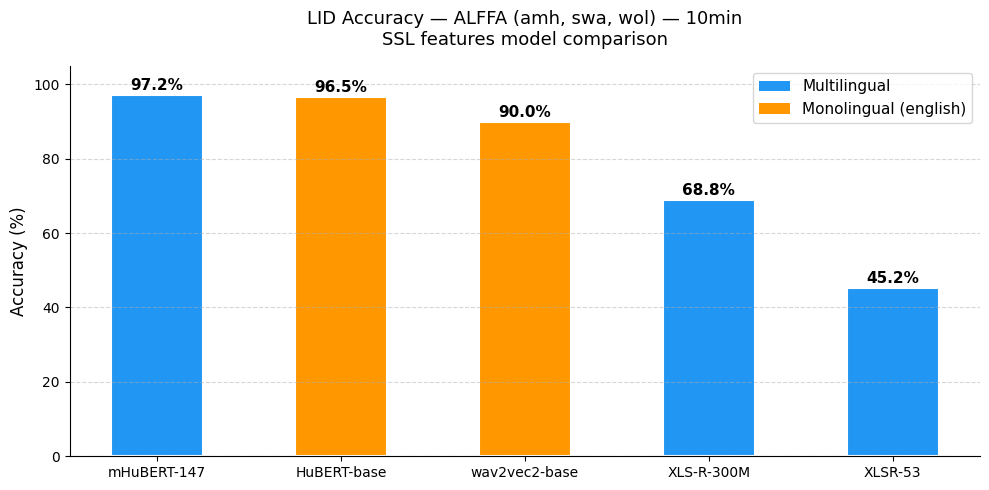

In [24]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


all_results = {}
for model_name in MODELS:
    path = RESULTS_DIR / f"lid_ALFFA_{model_name}_10min_results.json" # Load data to generate visualisation
    if not path.exists():
        print(f"No results for {model_name}")
        continue
    with open(path) as f:
        all_results[model_name] = json.load(f)

print(f" {len(all_results)}/5 models")

# ── 2. Tableau comparatif global ─────────────────────────────────────────────
rows = []
for model_name, res in all_results.items():
    rows.append({
        "Model": model_name,
        "Type": MODELS[model_name]["type"],
        "Accuracy (%)": round(res["test_accuracy"] * 100, 2),
        "Loss": round(res["test_loss"], 4),
    })

df_results = pd.DataFrame(rows).sort_values("Accuracy (%)", ascending=False)
print("\n Compared results:")
print(df_results.to_string(index=False))


fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#2196F3" if MODELS[m]["type"] == "multilingual"
          else "#FF9800" for m in df_results["Model"]]

bars = ax.bar(df_results["Model"], df_results["Accuracy (%)"],
              color=colors, edgecolor="white", linewidth=1.5, width=0.5)

for bar, val in zip(bars, df_results["Accuracy (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Multilingual"),
    Patch(facecolor="#FF9800", label="Monolingual (english)"),
]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_title("LID Accuracy — ALFFA (amh, swa, wol) — 10min\n"
             "SSL features model comparison",
             fontsize=13, pad=15)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_5models.png", dpi=150)
plt.show()